## Quantstats

In [14]:
import pandas as pd
%matplotlib inline
import quantstats as qs
file_name = "quantstats_report.html"

# fetch the daily returns for a stock
# stock = qs.utils.download_returns('FB')

# show sharpe ratio
# qs.stats.sharpe(stock)

# qs.plots.snapshot(stock, title='Facebook Performance')

# qs.reports.metrics(stock, "SPY", mode="full", compounded=False)
# qs.reports.metrics(stock, "SPY", mode="full")
# qs.reports.plots(stock, "SPY", mode="full")
# qs.reports.html(stock, "SPY", output=file_name)

In [15]:
from dateutil import parser
res = {}
for line in open("../../src/stats.csv", "r"):
    if "Value" not in line:
        stats = line.strip().split(",")
        dt, val = stats[0], stats[1]
        res[parser.parse(dt)] = float(val)
stock = pd.Series(res)
stock.index.tz_localize("UTC")

stock.head(5)

2019-03-01 00:00:00    10000.00
2019-03-04 00:00:00    10000.00
2019-03-04 16:16:00     9998.56
2019-03-05 00:00:00     9990.28
2019-03-06 00:00:00     9985.60
dtype: float64

                           Strategy
-------------------------  ----------
Start Period               2019-03-01
End Period                 2021-06-16
Risk-Free Rate             0.0%
Time in Market             100.0%

Cumulative Return          124.47%
CAGR%                      42.22%

Sharpe                     1.54
Sortino                    2.89
Sortino/√2                 2.05

Max Drawdown               -8.33%
Longest DD Days            83
Volatility (ann.)          11.75%
Calmar                     5.07
Skew                       3.37
Kurtosis                   36.97

Expected Daily %           0.07%
Expected Monthly %         2.83%
Expected Yearly %          30.93%
Kelly Criterion            15.3%
Risk of Ruin               0.0%
Daily Value-at-Risk        -1.15%
Expected Shortfall (cVaR)  -1.15%

Gain/Pain Ratio            0.62
Gain/Pain (1M)             8.31

Payoff Ratio               1.34
Profit Factor              1.42
Common Sense Ratio         2.02
CPC Index                

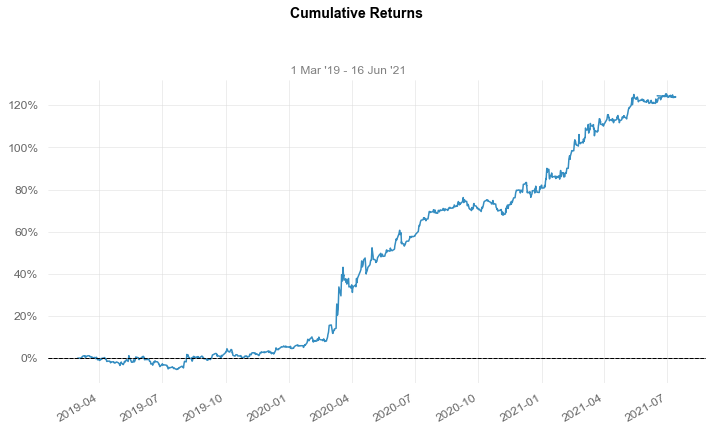

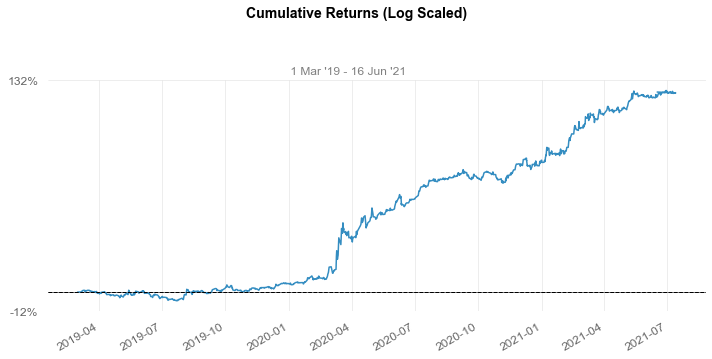

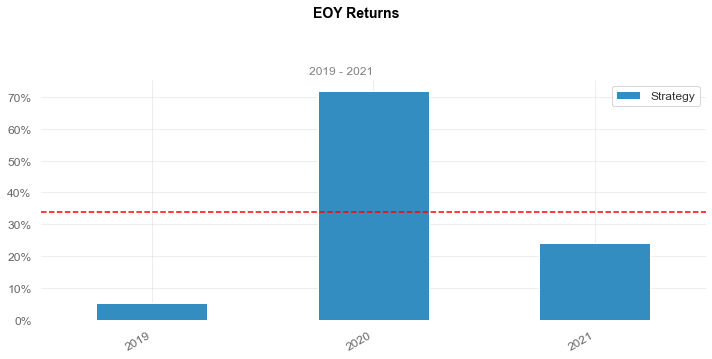

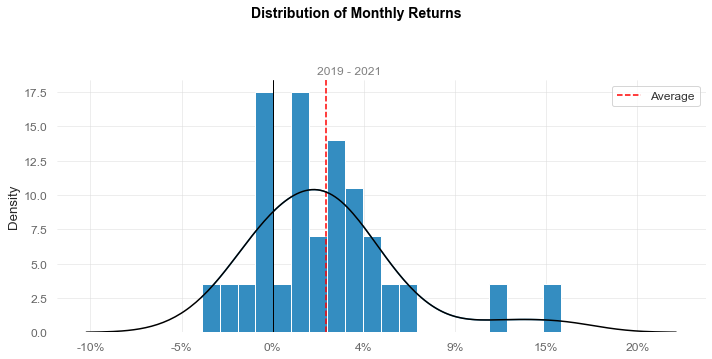

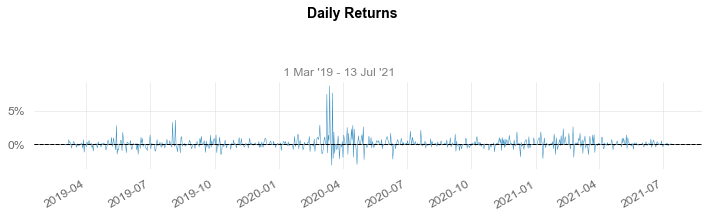

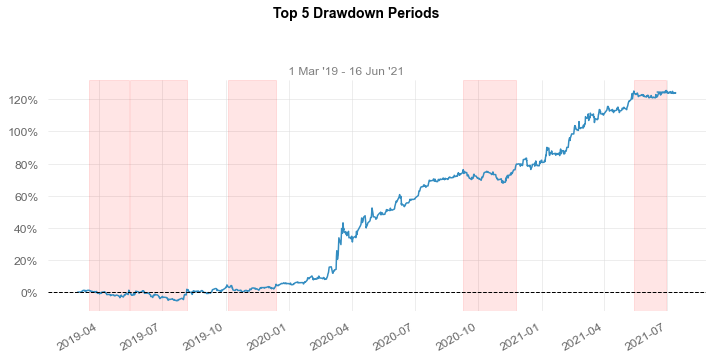

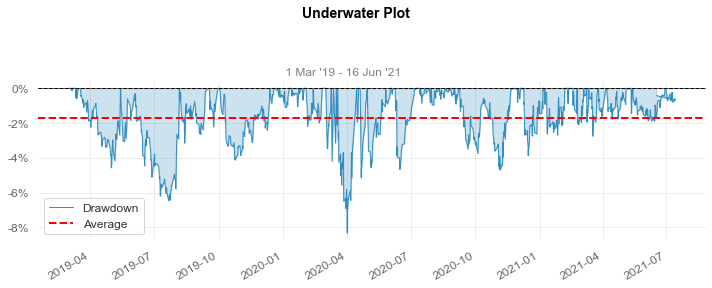

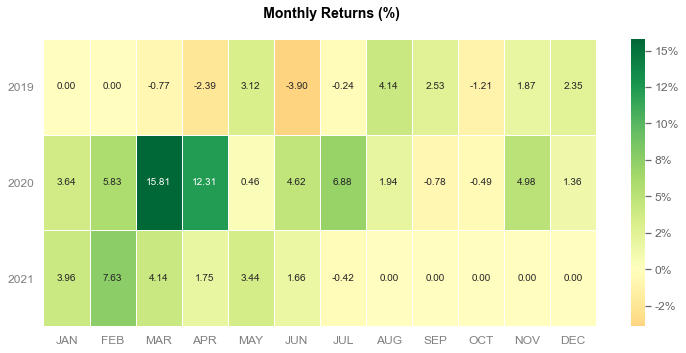

In [16]:
qs.reports.metrics(stock, mode="full")
qs.reports.plots(stock, mode="full", figsize=(10, 5))

In [17]:
qs.reports.html(stock, output=file_name)

import webbrowser, os
_ = webbrowser.open('file:///' + os.path.realpath(file_name))
